In [1]:
from fastai.vision.all import * 

In [2]:
import torch.nn as nn
import torch

In [3]:
from make import load_secondary_data, load_heath_assessment_test_data
spec, labels = load_secondary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [29]:
len(spec)

600

In [4]:
from validation_util import split

valid, valid_labels = load_heath_assessment_test_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 

In [43]:
class CNN1D(nn.Module):
    def __init__(self, n_classes: int, target_hw=(112, 112)):
        super().__init__()
        self.target_hw = target_hw
        
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),
        )
        
        # Infer flattened size automatically
        with torch.no_grad():
            dummy = torch.zeros(1, 3, *self.target_hw)
            out = self.feature_extractor(dummy)
            self.flattened_size = out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flattened_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),   # raw logits for CrossEntropyLoss
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        return self.classifier(x)

In [44]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [45]:
import matplotlib.pyplot as plt
import numpy as np

In [46]:
def get_x(i : int):
        arr = spec[i]

        # If spectrogram is multi-channel, convert to grayscale first
        if len(arr.shape) == 3:
                arr = np.mean(arr, axis=-1)  # average across channels
        
        #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
        
        # Apply colormap to convert grayscale to color
        # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
        colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
        arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
        
        # Convert RGBA to RGB (drop alpha channel)
        arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
        
        # Convert to PyTorch tensor with correct channel ordering
        t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
        
        # Resize image
        t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
        
        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return labels[i]

In [47]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [48]:
items = list(range(len(spec)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

In [75]:
model = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=2),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),
            
            nn.Conv2d(8, 16, kernel_size=3, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(16*6*6, 14),   # raw logits for CrossEntropyLoss
        )

In [76]:
learner = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

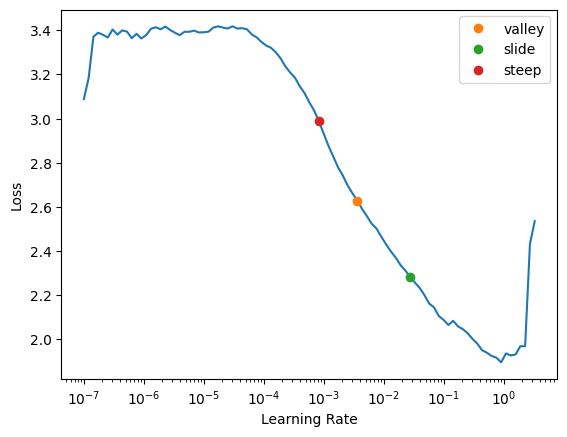

In [77]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))

In [78]:
learner.fine_tune(20)

epoch,train_loss,valid_loss,accuracy,time
0,1.662508,1.117061,0.325000,00:00


epoch,train_loss,valid_loss,accuracy,time
0,1.095268,0.943862,0.600000,00:00
1,1.039616,0.918702,0.591667,00:00
2,1.007694,0.841484,0.700000,00:00
3,0.937668,0.780059,0.666667,00:00
4,0.892066,0.704783,0.766667,00:00
5,0.855560,0.666950,0.808333,00:00
6,0.802086,0.618219,0.800000,00:00
7,0.744512,0.588017,0.808333,00:00
8,0.709666,0.555815,0.816667,00:00
9,0.702322,0.561592,0.808333,00:00


In [79]:
learner.unfreeze()

In [80]:
learner.fit_one_cycle(30, lr.valley)

epoch,train_loss,valid_loss,accuracy,time


In [93]:
dir = Path('./models')

learner.path = dir

learner.export('hybrid.pkl')

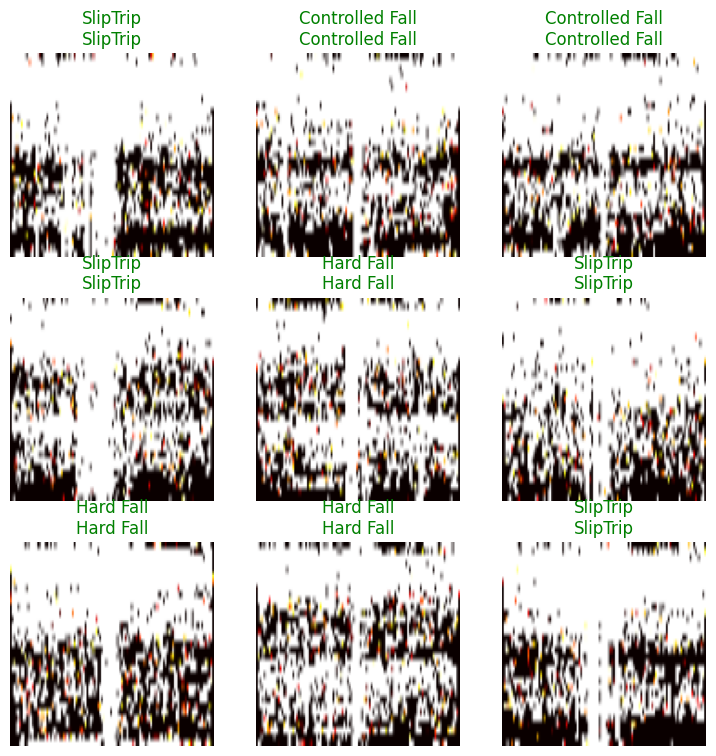

In [81]:
learner.show_results()

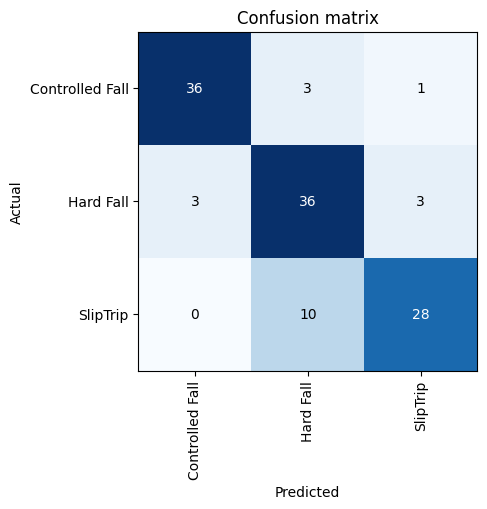

In [82]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [83]:
def get_x_test(i):
    arr = valid[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
        arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [84]:
learner.validate()

(#2) [0.41019514203071594,0.8333333134651184]

In [85]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test 

In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [87]:
y_pred, y_test = get_y_pred(learner, valid)

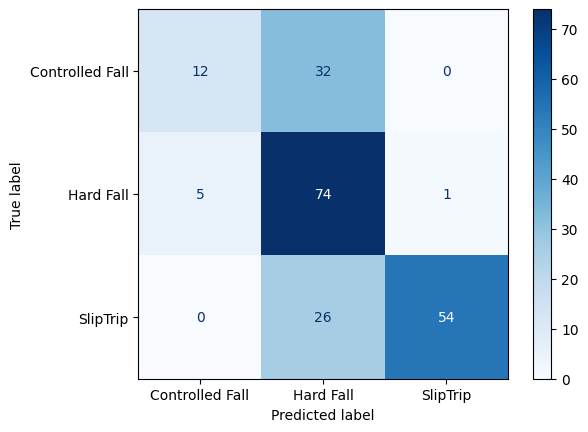

In [88]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [89]:
accuracy_score(y_test, y_pred)

0.6862745098039216

In [90]:
precision_score(y_test, y_pred, average='weighted')

0.7571213868791723

In [91]:
recall_score(y_test, y_pred, average="weighted")

0.6862745098039216

In [92]:
f1_score(y_test, y_pred, average="weighted")

0.6723555490863218